# Machine Learning 2 - Neural Networks

In this lab, we will use simple Neural Networks to classify the images from the simplified CIFAR-10 dataset. We will compare our results with those obtained with Decision Trees and Random Forests.

Lab objectives
----
* Classification with neural networks
* Influence of hidden layers and of the selected features on the classifier results

In [1]:
from lab_tools import CIFAR10, evaluate_classifier, get_hog_image
        
dataset = CIFAR10('CIFAR10/')

Pre-loading training data
Pre-loading test data


We will use the *[Multi-Layer Perceptron](http://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html#sklearn.neural_network.MLPClassifier)* implementation from scikit-learn, which is only available since version 0.18. You can check which version of scikit-learn is installed by executing this :

In [2]:
import sklearn
print(sklearn.__version__)

1.8.0


If you have version 0.17 or older, please update your scikit-learn installation (for instance, with the command *pip install scikit-learn==0.19.1* in the terminal or Anaconda prompt)

## Build a simple neural network

* Using the [MLPClassifier](http://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html) from scikit-learn, create a neural network with a single hidden layer.
* Train this network on the CIFAR dataset.
* Using cross-validation, try to find the best possible parameters.

In [15]:
from sklearn.neural_network import MLPClassifier

## -- Your code here -- ##
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score

X_train = dataset.train["hog"]
X_test = dataset.test["hog"]
y_train = dataset.train["labels"]
y_test = dataset.test["labels"]

clf = MLPClassifier() # default hidden_layer_sizes=(100,) = 1 layer of 100 neurons
scores = cross_val_score(estimator=clf, X=X_train, y=y_train, cv=10)


d:\anaconda3\envs\imaging\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
d:\anaconda3\envs\imaging\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
d:\anaconda3\envs\imaging\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
d:\anaconda3\envs\imaging\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
d:\anaconda3\envs\imaging\Lib\site-packages\sklearn\neural_network\_

In [16]:
print(scores)

[0.78866667 0.79333333 0.782      0.81466667 0.76866667 0.784
 0.79666667 0.788      0.79133333 0.80066667]


In [17]:
from sklearn.model_selection import StratifiedKFold

kf = StratifiedKFold(5)

for train,test in kf.split(dataset.train['hog'], dataset.train['labels']):
    train_x = dataset.train['hog'][train]
    train_y = dataset.train['labels'][train]
    
    test_x = dataset.train['hog'][test]
    test_y = dataset.train['labels'][test]

## Add hidden layers to the network.

Try to change the structure of the network by adding hidden layers. Using cross-validation, try to find the best architecture for your network.

In [22]:
## -- Your code here -- ##
import numpy as np

all_splits_200 = []

for hl in [1,2,3,4,5]:
    clf = MLPClassifier(hidden_layer_sizes=(100,hl))
    cv_splits = cross_val_score(estimator=clf, X=X_train, y=y_train, cv=10)
    print(f"hidden_layers = {hl} : accuracy = {np.mean(cv_splits):.04f} +/- {np.std(cv_splits):.04f}")
    all_splits_200.append(cv_splits)


d:\anaconda3\envs\imaging\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
d:\anaconda3\envs\imaging\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
d:\anaconda3\envs\imaging\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
d:\anaconda3\envs\imaging\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
d:\anaconda3\envs\imaging\Lib\site-packages\sklearn\neural_network\_

hidden_layers = 1 : accuracy = 0.5387 +/- 0.2056


d:\anaconda3\envs\imaging\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
d:\anaconda3\envs\imaging\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
d:\anaconda3\envs\imaging\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


hidden_layers = 2 : accuracy = 0.4603 +/- 0.1943


d:\anaconda3\envs\imaging\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
d:\anaconda3\envs\imaging\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
d:\anaconda3\envs\imaging\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
d:\anaconda3\envs\imaging\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
d:\anaconda3\envs\imaging\Lib\site-packages\sklearn\neural_network\_

...

d:\anaconda3\envs\imaging\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
d:\anaconda3\envs\imaging\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
d:\anaconda3\envs\imaging\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
d:\anaconda3\envs\imaging\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
d:\anaconda3\envs\imaging\Lib\site-packages\sklearn\neural_network\_

hidden_layers = 4 : accuracy = 0.6947 +/- 0.1811


d:\anaconda3\envs\imaging\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
d:\anaconda3\envs\imaging\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
d:\anaconda3\envs\imaging\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
d:\anaconda3\envs\imaging\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
d:\anaconda3\envs\imaging\Lib\site-packages\sklearn\neural_network\_

hidden_layers = 5 : accuracy = 0.7271 +/- 0.1371


d:\anaconda3\envs\imaging\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


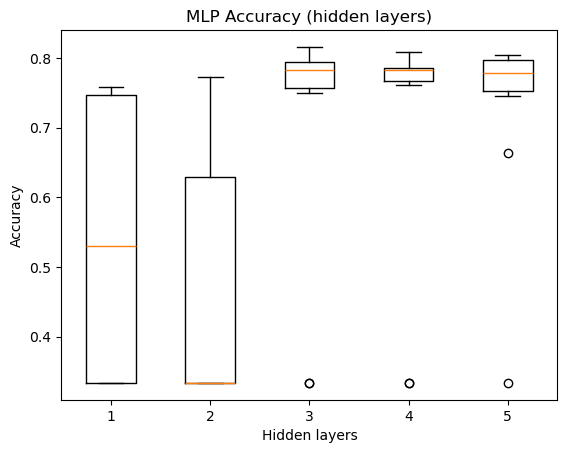

In [55]:
import matplotlib.pyplot as plt


plt.figure()
plt.boxplot(all_splits_200)

plt.title("MLP Accuracy (hidden layers)")
plt.xlabel("Hidden layers")
plt.ylabel("Accuracy")
plt.show()

In [ ]:
all_splits_5000 = []

for hl in [1,2,3,4,5]:
    clf = MLPClassifier(hidden_layer_sizes=(100,hl), max_iter=5000)
    cv_splits = cross_val_score(estimator=clf, X=X_train, y=y_train, cv=10)
    print(f"hidden_layers = {hl} : accuracy = {np.mean(cv_splits):.04f} +/- {np.std(cv_splits):.04f}")
    all_splits_5000.append(cv_splits)




d:\anaconda3\envs\imaging\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:792: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")
d:\anaconda3\envs\imaging\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:792: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")


hidden_layers = 1 : accuracy = 0.4449 +/- 0.1704


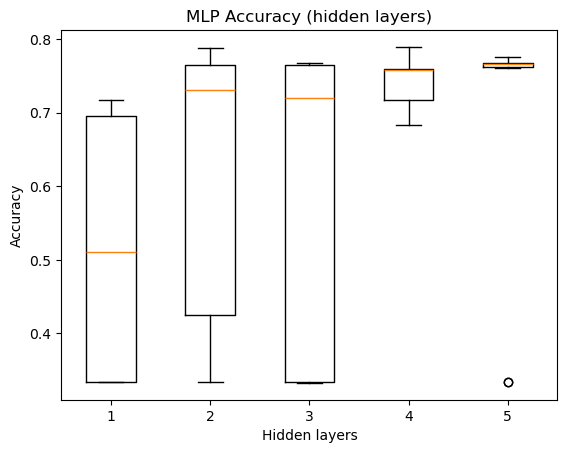

In [ ]:
import matplotlib.pyplot as plt


plt.figure()
plt.boxplot(all_splits)

plt.title("MLP Accuracy (hidden layers)")
plt.xlabel("Hidden layers")
plt.ylabel("Accuracy")
plt.show()

d:\anaconda3\envs\imaging\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
d:\anaconda3\envs\imaging\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
d:\anaconda3\envs\imaging\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
d:\anaconda3\envs\imaging\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
d:\anaconda3\envs\imaging\Lib\site-packages\sklearn\neural_network\_

hidden_layers = 1 : accuracy = 0.5255 +/- 0.1934


d:\anaconda3\envs\imaging\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
d:\anaconda3\envs\imaging\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
d:\anaconda3\envs\imaging\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
d:\anaconda3\envs\imaging\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
d:\anaconda3\envs\imaging\Lib\site-packages\sklearn\neural_network\_

hidden_layers = 2 : accuracy = 0.5234 +/- 0.1936


d:\anaconda3\envs\imaging\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
d:\anaconda3\envs\imaging\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
d:\anaconda3\envs\imaging\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
d:\anaconda3\envs\imaging\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
d:\anaconda3\envs\imaging\Lib\site-packages\sklearn\neural_network\_

hidden_layers = 3 : accuracy = 0.6950 +/- 0.1811


d:\anaconda3\envs\imaging\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
d:\anaconda3\envs\imaging\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
d:\anaconda3\envs\imaging\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
d:\anaconda3\envs\imaging\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
d:\anaconda3\envs\imaging\Lib\site-packages\sklearn\neural_network\_

hidden_layers = 4 : accuracy = 0.6966 +/- 0.1820


d:\anaconda3\envs\imaging\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
d:\anaconda3\envs\imaging\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
d:\anaconda3\envs\imaging\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
d:\anaconda3\envs\imaging\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
d:\anaconda3\envs\imaging\Lib\site-packages\sklearn\neural_network\_

hidden_layers = 5 : accuracy = 0.7395 +/- 0.1364
hidden_layers = 1 : accuracy = 0.4478 +/- 0.1752
hidden_layers = 2 : accuracy = 0.5794 +/- 0.2023
hidden_layers = 3 : accuracy = 0.6407 +/- 0.2016
hidden_layers = 4 : accuracy = 0.7267 +/- 0.1316
hidden_layers = 5 : accuracy = 0.7162 +/- 0.1304


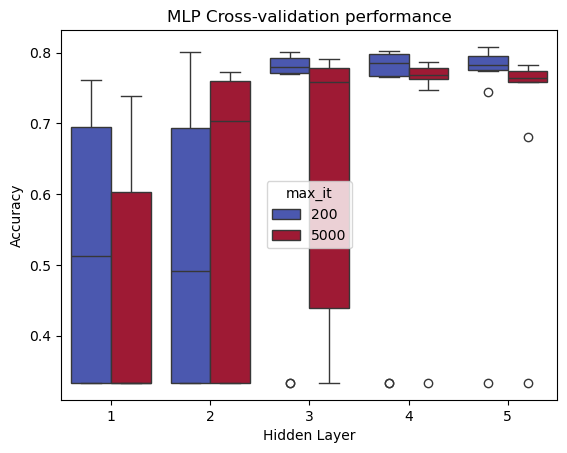

In [3]:
# Combined plot

# ====== Load Dataset =========
X_train = dataset.train["hog"]
X_test = dataset.test["hog"]
y_train = dataset.train["labels"]
y_test = dataset.test["labels"]

# =========== CV  ===========
import numpy as np
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score

all_splits_200 = []
all_splits_5000 = []

for hl in [1,2,3,4,5]:
    clf = MLPClassifier(hidden_layer_sizes=(100,hl))
    cv_splits = cross_val_score(estimator=clf, X=X_train, y=y_train, cv=10)
    print(f"hidden_layers = {hl} : accuracy = {np.mean(cv_splits):.04f} +/- {np.std(cv_splits):.04f}")
    all_splits_200.append(cv_splits)


for hl in [1,2,3,4,5]:
    clf = MLPClassifier(hidden_layer_sizes=(100,hl), max_iter=5000)
    cv_splits = cross_val_score(estimator=clf, X=X_train, y=y_train, cv=10)
    print(f"hidden_layers = {hl} : accuracy = {np.mean(cv_splits):.04f} +/- {np.std(cv_splits):.04f}")
    all_splits_5000.append(cv_splits)



# ======== Plot ==========

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


df200 = pd.DataFrame(np.asarray(all_splits_200))
df200 = df200.reset_index(names="n_hidden_layers") # Keep the current index as the number of hidden layers
df200["n_hidden_layers"] = df200["n_hidden_layers"] + 1 # Convert 0,1,2,3,4 to 1,2,3,4,5
df200["max_it"] = 200 # add max it column

df5000 = pd.DataFrame(np.asarray(all_splits_5000))
df5000 = df5000.reset_index(names="n_hidden_layers") # Keep the current index as the number of hidden layers
df5000["n_hidden_layers"] = df5000["n_hidden_layers"] + 1 # Convert 0,1,2,3,4 to 1,2,3,4,5
df5000["max_it"] = 5000 # add max it column


df = pd.concat([df200, df5000])

# Mise au format long
df_long = df.melt(
    id_vars=["max_it", "n_hidden_layers"],
    var_name="cv_split",
    value_name="score"
)

sns.boxplot(
    data=df_long,
    x="n_hidden_layers",
    y="score",
    hue="max_it",
    palette="coolwarm"
)

plt.xlabel("Hidden Layer")
plt.ylabel("Accuracy")
plt.title("MLP Cross-validation performance")
plt.show()

In [53]:
display(df)

,n_hidden_layers,0,1,2,3,4,5,6,7,8,9,max_it
0,1,0.333333,0.758000,0.333333,0.333333,0.751333,0.333333,0.752000,0.732667,0.726667,0.333333,200
1,2,0.728000,0.333333,0.333333,0.773333,0.333333,0.333333,0.333333,0.768667,0.333333,0.333333,200
2,3,0.778667,0.784000,0.333333,0.816000,0.750000,0.333333,0.785333,0.799333,0.796667,0.782667,200
3,4,0.786000,0.794667,0.782667,0.809333,0.782000,0.781333,0.333333,0.783333,0.333333,0.761333,200
4,5,0.745333,0.802667,0.777333,0.333333,0.774000,0.790000,0.804667,0.780667,0.664000,0.799333,200
0,1,0.696667,0.710667,0.333333,0.333333,0.686667,0.333333,0.694000,0.333333,0.333333,0.716667,1000
1,2,0.762667,0.333333,0.764667,0.333333,0.702000,0.787333,0.770000,0.754000,0.707333,0.333333,1000
2,3,0.766000,0.333333,0.699333,0.333333,0.764667,0.762667,0.740000,0.332667,0.768000,0.333333,1000
3,4,0.723333,0.772667,0.716000,0.789333,0.757333,0.760000,0.757333,0.697333,0.759333,0.683333,1000
4,5,0.769333,0.766667,0.775333,0.333333,0.764667,0.766667,0.766000,0.760667,0.768000,0.333333,1000
